<a href="https://colab.research.google.com/github/AnjanaGunarathna/ML-News-Detection/blob/Anjana--RandomForest/FakeNewsDetection_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Fake = pd.read_csv("/content/Fake.csv")
TrueNews = pd.read_csv("/content/True.csv")

Fake['label'] = 0
TrueNews['label'] = 1

Fake.drop(columns=["title", "subject", "date"], inplace=True)
TrueNews.drop(columns=["title", "subject", "date"], inplace=True)

News = pd.concat([Fake, TrueNews], ignore_index=True)

# Shuffle + remove duplicates
News = News.sample(frac=1, random_state=42).reset_index(drop=True)
News.drop_duplicates(inplace=True)

print("Dataset size:", News.shape)
print(News['label'].value_counts())

Dataset size: (38647, 2)
label
1    21192
0    17455
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)

    # Remove dataset bias words
    text = re.sub(r'reuters|associated press|ap news', '', text)

    # Keep only letters
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

News['clean_text'] = News['text'].apply(clean_text)

In [ ]:
X = News['clean_text']
y = News['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

In [ ]:
param_dist = {
    'tfidf__max_features': [2000, 3000, 4000],
    'tfidf__ngram_range': [(1,1)],
    'tfidf__max_df': [0.5, 0.6],
    'tfidf__min_df': [5, 10],

    'rf__n_estimators': [100, 150, 200],
    'rf__max_depth': [8, 10, 12],
    'rf__min_samples_split': [10, 15, 20],
    'rf__min_samples_leaf': [5, 8, 10],
    'rf__max_features': ['sqrt']
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:\n", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
 {'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 10, 'tfidf__max_features': 3000, 'tfidf__max_df': 0.5, 'rf__n_estimators': 200, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 8, 'rf__max_features': 'sqrt', 'rf__max_depth': 12}


In [ ]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9411384217335058

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93      3491
           1       0.92      0.98      0.95      4239

    accuracy                           0.94      7730
   macro avg       0.95      0.94      0.94      7730
weighted avg       0.94      0.94      0.94      7730



In [ ]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.94210867 0.94162354 0.94404011 0.94484878 0.94177584]
Mean CV Accuracy: 0.9428793876043292


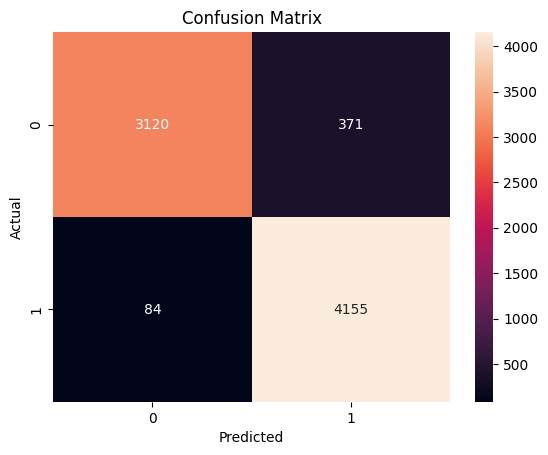

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

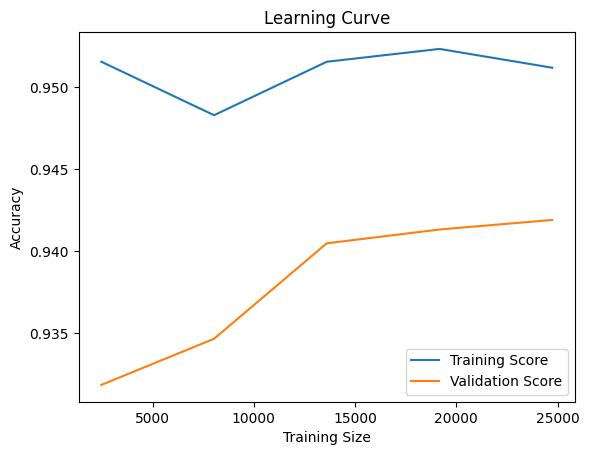

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

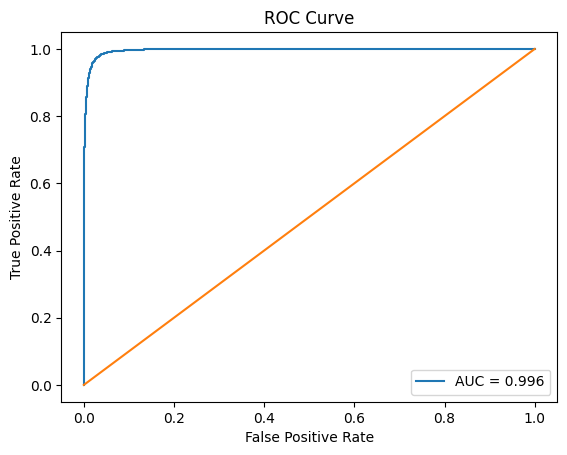

In [ ]:
y_probs = best_rf.predict_proba(X_test_tfidf)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

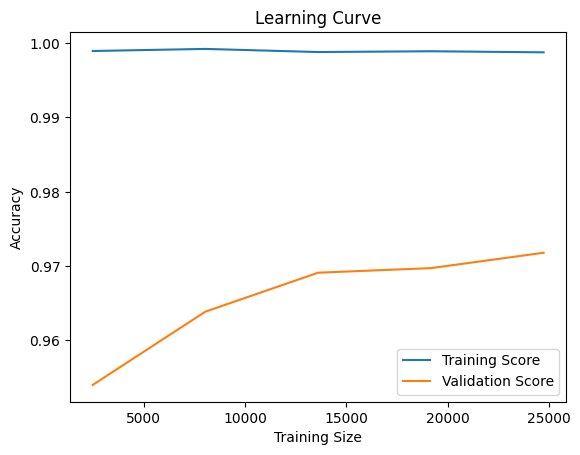

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_tfidf, y_train, cv=5, n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

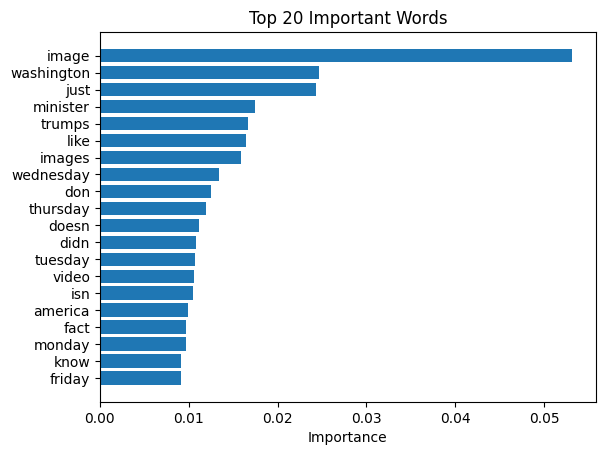

In [ ]:
import numpy as np

importances = best_rf.feature_importances_
indices = np.argsort(importances)[-20:]

feature_names = tfidf.get_feature_names_out()

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Top 20 Important Words")
plt.xlabel("Importance")
plt.show()